In [1]:
import sys
sys.path.append("..")

import jax
from jax import flatten_util, vmap 
import jax.numpy as jnp
import jax.random as jr
import os
import matplotlib.pyplot as plt
from physical_diffusion_fns.helper_fns import sample_gaussian_mixture, normalize_samples, sample_forward_process, get_best_params, smooth_parameters, interpolate_parameters
from physical_diffusion_fns.learning_fns import setup_MLE_loss_per_batch, setup_MLE_gradient_per_batch, CD1_gradient, setup_score_matching_loss_per_batch, run_optimization, setup_score_matching_kbT_loss_per_batch, setup_score_matching_kbT_local_gradient_per_batch
from physical_diffusion_fns.plotting_fns import plot_energy_and_distributions, plot_parameter_evolution, plot_forward_marginals, visualize_connectivity, plot_parameter_as_fn_of_time, visualize_connectivity_with_non_local_couplings
from physical_diffusion_fns.network_fns import setup_duffing_network_with_external_force_energy_fn, setup_overdamped_SDE, solve_SDE, create_2d_square_lattice_connectivity, setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn,setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn

jax.config.update("jax_enable_x64", True)

2025-06-11 01:34:33.337421: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.8.93. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


# Random keys

In [2]:
master_key  = jax.random.PRNGKey(0)          # single seed
sample_target_key, optimization_key, reverse_sde_key = jr.split(master_key, 3)

# Generate samples from a Gaussian mixture - the target distribution

In [3]:
# Parameters
N = 2  # number of dimensions
N_mixgauss = 3  # number of mixture components
n_samples = 10000

# Define mixture weights (must sum to 1)
weights = jnp.array([.6, .4])

# Define means
means = jnp.array([
    [1., 0.5],   # mean of first Gaussian
    [-1., -0.5],  # mean of second Gaussian
])

# Define covariance matrices
covs = jnp.array([
    [[0.001, 0.0],    # covariance of first Gaussian
        [0.0, 0.001]],
    [[0.001, 0.0],   # covariance of second Gaussian
        [0.0, 0.001]],
])
# Generate samples
samples_target = sample_gaussian_mixture(sample_target_key, n_samples, weights, means, covs)
# Normalize samples
# samples = normalize_samples(samples_raw)



### Plot samples and marginal of target distributions

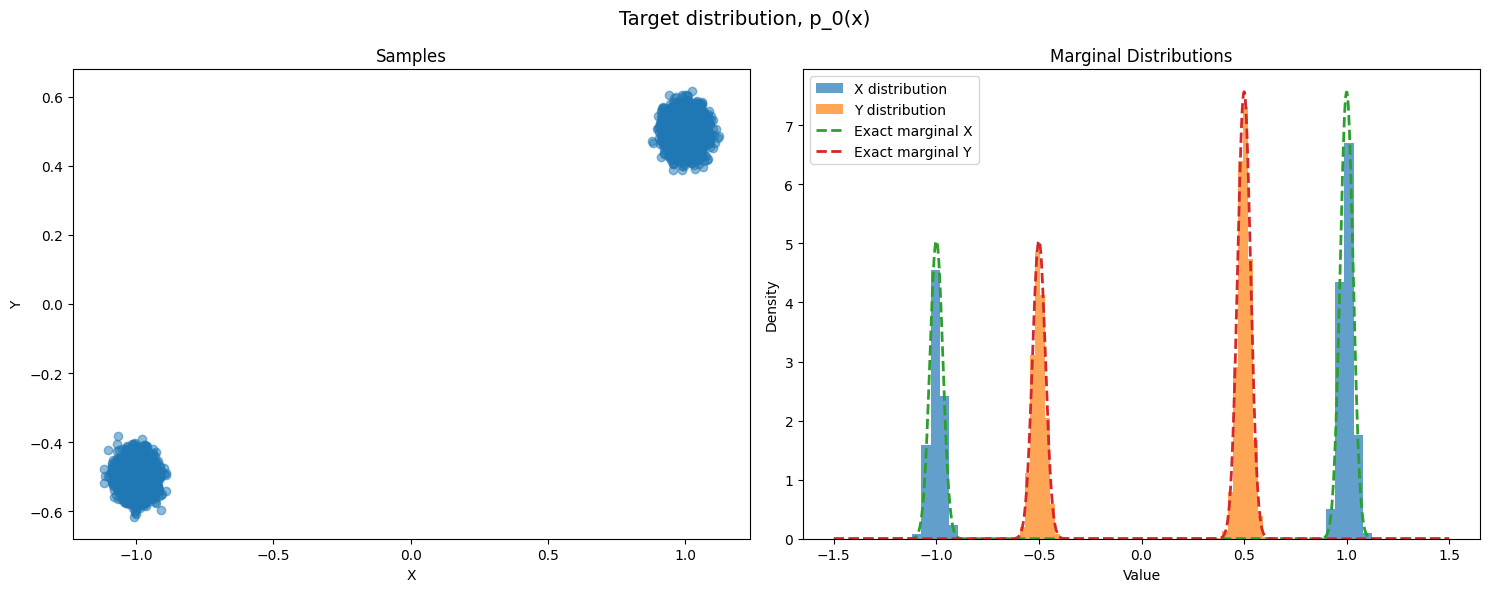

In [4]:
# Plot samples and marginal distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Target distribution, p_0(x)', fontsize=14)

# First subplot: Scatter plot of samples
ax1.scatter(samples_target[:, 0], samples_target[:, 1], alpha=0.5)
ax1.set_title('Samples')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Second subplot: Combined marginal distributions
ax2.hist(samples_target[:, 0], bins=50, density=True, alpha=0.7, label='X distribution')
ax2.hist(samples_target[:, 1], bins=50, density=True, alpha=0.7, label='Y distribution')

# Add exact marginal Gaussians
x = jnp.linspace(-1.5, 1.5, 1000)
for dim in range(2):
    marginal = jnp.zeros_like(x)
    for w, m, c in zip(weights, means, covs):
        mean = m[dim]
        std = jnp.sqrt(c[dim, dim])
        marginal += w * jnp.exp(-0.5 * ((x - mean) / std) ** 2) / (std * jnp.sqrt(2 * jnp.pi))
    ax2.plot(x, marginal, '--', linewidth=2, label=f'Exact marginal {["X", "Y"][dim]}')

ax2.set_title('Marginal Distributions')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.legend()

plt.tight_layout()
plt.show()

# Physical system

## Network size and topology and temperature

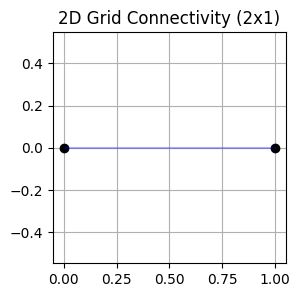

In [5]:
Temp = 0.01
N_osc = 2
connectivity = jnp.array([[0, 1]])
num_connections = connectivity.shape[0]
visualize_connectivity(connectivity,grid_size_x=2,grid_size_y=1)

## Energy

In [6]:
energy_fn_type = "6th_order_duffing_coupling"
if energy_fn_type == "6th_order_duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    k_6_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, k_6_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'k_6', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_k6_self = jnp.arange(2*N_osc,3*N_osc)
    constraint_indices = constraint_indices_k6_self

    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_and_6th_order_energy_fn(connectivity, unflatten)
elif energy_fn_type == "duffing_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    c_duff_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, c_duff_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'c_duff', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices_duff_self = jnp.arange(N_osc,2*N_osc)
    constraint_indices_duff_coupling = jnp.arange(2*N_osc+2*num_connections,2*N_osc+3*num_connections)
    constraint_indices = jnp.concatenate([constraint_indices_duff_self, constraint_indices_duff_coupling])
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_and_nonlinear_duffing_coupling_energy_fn(connectivity, unflatten)
elif energy_fn_type == "duffing_optomech_coupling":
    k_lin_0 = -1.*jnp.ones(N_osc)
    k_duff_0 = jnp.ones(N_osc)
    c_lin_0 = jnp.zeros(num_connections)
    c_optomech_0 = jnp.zeros(num_connections)
    biases_0 = jnp.zeros(N_osc)
    params_initial = (k_lin_0, k_duff_0, c_lin_0, c_optomech_0, biases_0)
    params_names = ['k_lin', 'k_duff', 'c_lin', 'c_optomech', 'biases']
    params_flattened_initial, unflatten = flatten_util.ravel_pytree(params_initial)
    constraint_indices = jnp.arange(N_osc,2*N_osc)
    # Set up energy fn
    energy_fn = setup_duffing_network_with_external_force_energy_fn(connectivity, unflatten)
else:
    raise ValueError(f"Unknown energy function type: {energy_fn_type}. Choose from '6th_order_duffing_coupling' or 'duffing_coupling'.")

### Plot initial energy landscape

Initial Parameters probability distribution total (should be ≈ 1): 1.000000


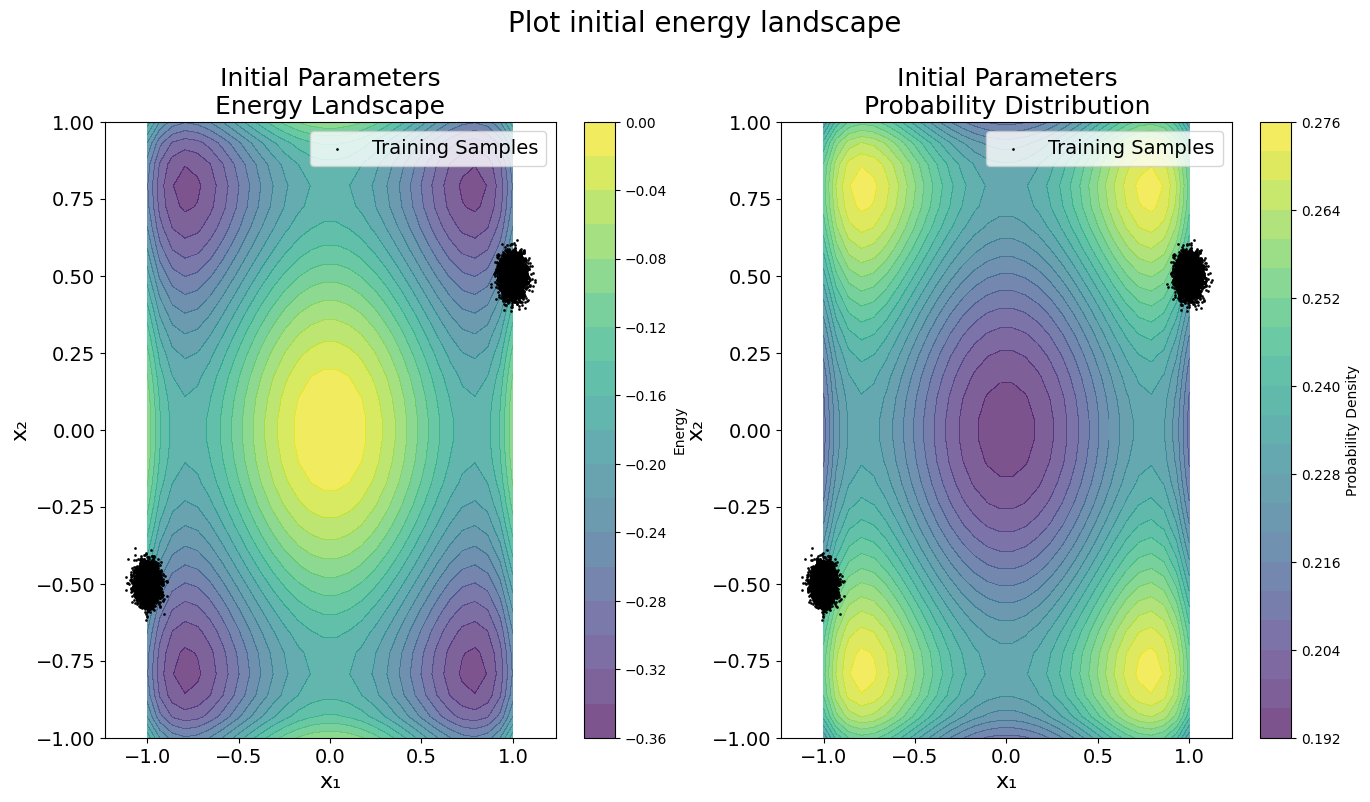

In [7]:
# Example usage:
param_list = [params_flattened_initial]
titles = ["Initial Parameters"]

plot_energy_and_distributions(
    energy_fn=energy_fn,
    param_list=param_list,
    samples=samples_target,
    x1_range=(-1, 1),   
    x2_range=(-1, 1),   
    n_points=30,       
    titles=titles,      
    figsize=(16, 8),   
    fontsize=16,        
    sample_stride=1,
    suptitle="Plot initial energy landscape" 
)

# Learning

In [8]:
lss_fn_per_batch_SM = setup_score_matching_loss_per_batch(energy_fn)
loss_fn_per_batch = setup_score_matching_kbT_loss_per_batch(energy_fn, k_b=1.0, T=Temp)
gradient_fn_per_batch = setup_score_matching_kbT_local_gradient_per_batch(energy_fn, k_b=1.0, T=Temp)


In [9]:
from jax import grad

grad(loss_fn_per_batch)(params_flattened_initial,samples_target)

Array([10109.81828867, -1804.28761675, 10083.83503066,  -505.91058376,
       10098.81753773,  -142.45298409, 13295.10444113,  1350.3302785 ,
        1638.4840659 ,  2047.76682351,  -693.69971473], dtype=float64)

In [10]:
gradient_fn_per_batch(params_flattened_initial,samples_target)

Array([10109.81828867, -1804.28761675, 10083.83503066,  -505.91058376,
       10098.81753773,  -142.45298409, 13295.10444113,  1350.3302785 ,
        1638.4840659 ,  2047.76682351,  -693.69971473], dtype=float64)

In [13]:
grad(lss_fn_per_batch_SM)(params_flattened_initial,samples_target)

Array([ 0.02098183, -1.17042876, -1.96528087, -0.79590659, -3.97214555,
       -0.33087236, -2.63048956, -0.06649086, -1.33391521,  0.20477668,
       -0.06936997], dtype=float64)

In [21]:
Temp**3

1.0000000000000002e-06

In [20]:
CD1_dt = 0.0001
CD1_num_noise_samples = 600
gradient_fn_per_batch = lambda flattened_args, batch, key_CD1: -CD1_gradient(energy_fn, samples_target, flattened_args, dt=CD1_dt, D=Temp, key=key_CD1, num_noise_samples=CD1_num_noise_samples)
gradient_fn_per_batch(params_flattened_initial,samples_target,sample_target_key)

2025-06-11 01:40:00.728307: W external/xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 91.55MiB (rounded to 96000000)requested by op 
2025-06-11 01:40:00.728727: W external/xla/xla/tsl/framework/bfc_allocator.cc:508] ****************************************************************************************************
E0611 01:40:00.728769   20435 pjrt_stream_executor_client.cc:3067] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 96000000 bytes.


KeyboardInterrupt: 